In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ryanbadai/clothes-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.37G/1.37G [00:11<00:00, 127MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1):
['Clothes_Dataset']


In [ ]:
import os

# Explore the structure inside 'Clothes_Dataset'
clothes_path = os.path.join(path, 'Clothes_Dataset')
if os.path.exists(clothes_path):
    print(f"Subdirectories in Clothes_Dataset: {os.listdir(clothes_path)}")
else:
    print(f"Directory {clothes_path} does not exist. Please check the file structure.")

Subdirectories in Clothes_Dataset: ['Celana_Panjang', 'Gaun', 'Jaket_Denim', 'Celana_Pendek', 'Rok', 'Blazer', 'Jaket_Olahraga', 'Kaos', 'Polo', 'Hoodie', 'Jeans', 'Sweter', 'Mantel', 'Kemeja', 'Jaket']


Found 7500 images. Displaying 6 sample images:


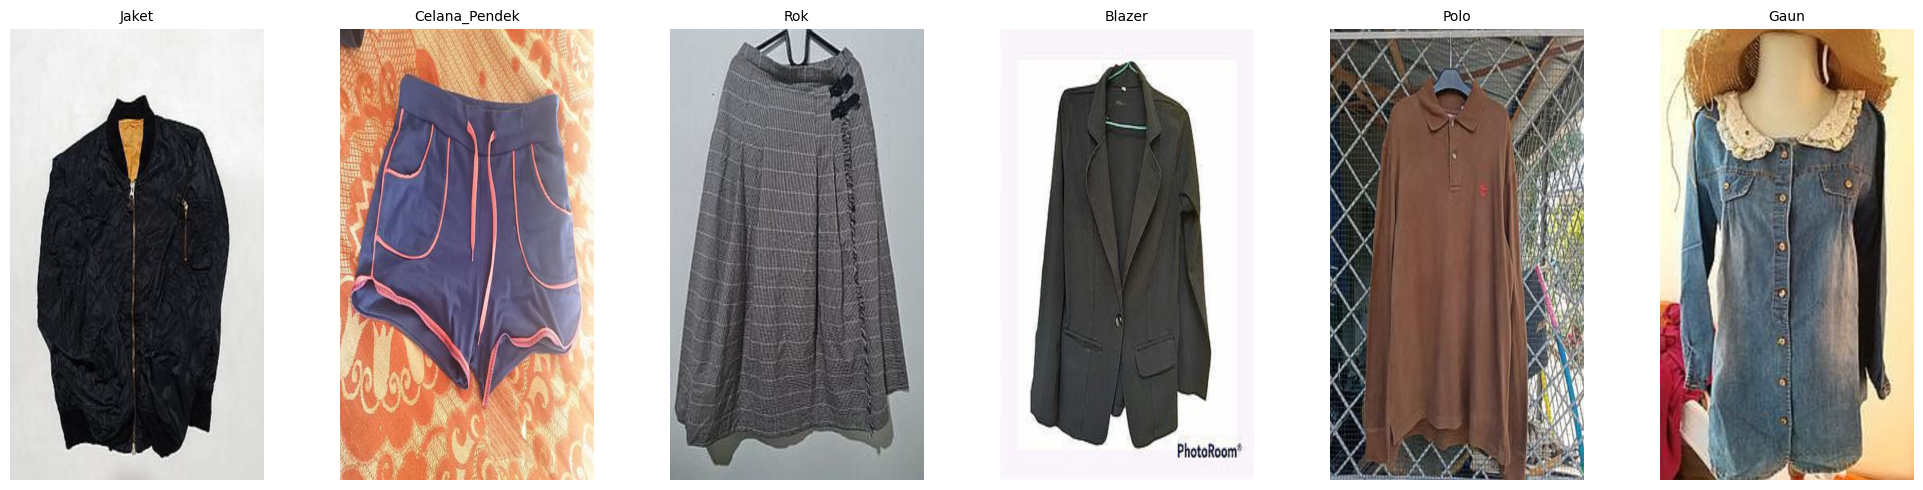

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1: axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the actual path of the clothes dataset
clothes_path = os.path.join(path, 'Clothes_Dataset')
display_sample_images(clothes_path)

In [ ]:
import os

# Define paths for the clothes dataset
input_folder = os.path.join(path, 'Clothes_Dataset')
output_folder = '/content/clothes_dataset_split'

if os.path.exists(input_folder):
    print(f"Preparing to split clothes data from: {input_folder}")
else:
    print(f"Error: {input_folder} not found.")

Preparing to split clothes data from: /root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1/Clothes_Dataset


In [ ]:
!pip install split-folders

In [ ]:
import os
try:
    import splitfolders
except ImportError:
    !pip install split-folders
    import splitfolders

# Split the clothes dataset: train=0.8, val(test)=0.2
# seed=42 for reproducibility
if os.path.exists(input_folder):
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)
    print(f"Clothes dataset split successfully into: {output_folder}")

Copying files: 7500 files [00:05, 1261.77 files/s]

Clothes dataset split successfully into: /content/clothes_dataset_split


In [ ]:
# Check the directory structure of the split clothes dataset
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 1: # Showing top level folders (train/val)
        print(f"{indent}{os.path.basename(root)}/")

clothes_dataset_split/
    train/
    val/


In [ ]:
import os

def count_files(directory):
    if not os.path.exists(directory):
        return 0
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"Clothes Dataset Statistics:")
if total > 0:
    print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%) -- Target: 80%")
    print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%) -- Target: 20%")
    print(f"- Total images: {total}")
else:
    print("No images found. Please ensure the split command in the previous cell executed successfully.")

Clothes Dataset Statistics:
- Train Set: 6000 images (80.0%) -- Target: 80%
- Test Set (val): 1500 images (20.0%) -- Target: 20%
- Total images: 7500


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
# Data transformation for AlexNet (requires 224x224 input)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    x: datasets.ImageFolder(os.path.join(output_folder, x), data_transforms[x])
    for x in ['train', 'val']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# Define AlexNet model
model = models.alexnet(weights=None)
# Modify the output layer to match the number of classes in the dataset
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, len(class_names))

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model initialized with {len(class_names)} classes.")

Model initialized with 15 classes.


In [ ]:
num_epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting Training...")
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        print(f'Epoch {epoch}/{num_epochs - 1} | {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Starting Training...
Epoch 0/9 | train Loss: 2.7185 Acc: 0.0662
Epoch 0/9 | val Loss: 2.7089 Acc: 0.0667
Epoch 1/9 | train Loss: 2.7095 Acc: 0.0638
Epoch 1/9 | val Loss: 2.7082 Acc: 0.0667
Epoch 2/9 | train Loss: 2.7087 Acc: 0.0630
Epoch 2/9 | val Loss: 2.7081 Acc: 0.0667
Epoch 3/9 | train Loss: 2.7085 Acc: 0.0595
Epoch 3/9 | val Loss: 2.7081 Acc: 0.0667
Epoch 4/9 | train Loss: 2.7086 Acc: 0.0647
Epoch 4/9 | val Loss: 2.7095 Acc: 0.0667
Epoch 5/9 | train Loss: 2.7090 Acc: 0.0563
Epoch 5/9 | val Loss: 2.7081 Acc: 0.0667
Epoch 6/9 | train Loss: 2.7085 Acc: 0.0613
Epoch 6/9 | val Loss: 2.7081 Acc: 0.0667
Epoch 7/9 | train Loss: 2.7084 Acc: 0.0582
Epoch 7/9 | val Loss: 2.7081 Acc: 0.0667
Epoch 8/9 | train Loss: 2.7084 Acc: 0.0607
Epoch 8/9 | val Loss: 2.7081 Acc: 0.0667
Epoch 9/9 | train Loss: 2.7083 Acc: 0.0605
Epoch 9/9 | val Loss: 2.7081 Acc: 0.0667


In [ ]:
# Summary of Training Results
final_train_acc = history['train_acc'][-1] * 100
final_val_acc = history['val_acc'][-1] * 100

print("--- Training Summary ---")
print(f"Total Epochs: {num_epochs}")
print(f"Final Training Accuracy: {final_train_acc:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")

--- Training Summary ---
Total Epochs: 10
Final Training Accuracy: 6.05%
Final Validation Accuracy: 6.67%


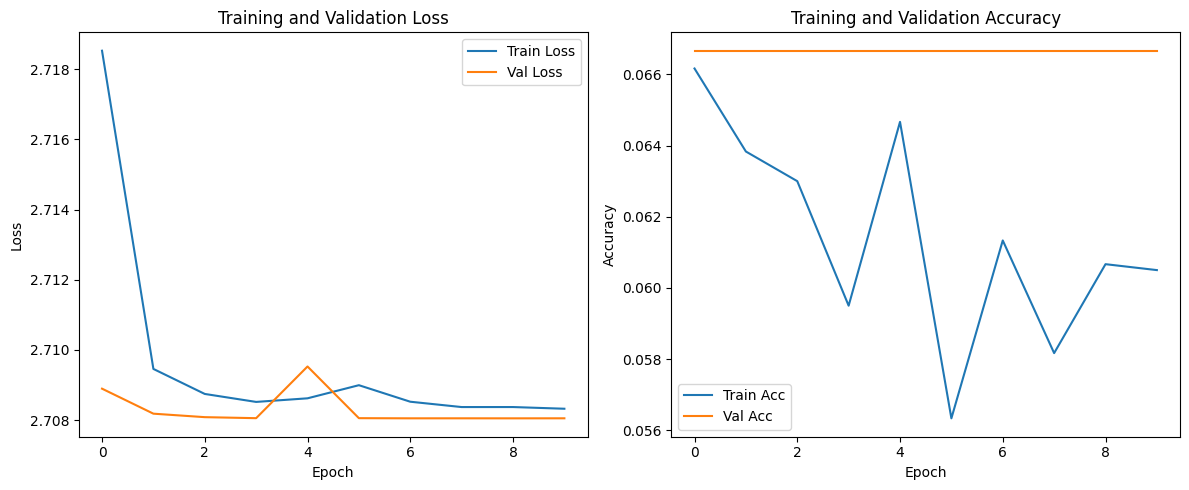

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()